In [337]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Physics utilities
# =========================

def energy(m0, m1, m2):
    return (m0**2 + m1**2 - m2**2) / (2 * m0)

def momentum(m0, m1, m2):
    return np.sqrt(np.maximum(energy(m0, m1, m2)**2 - m1**2, 0))


# =========================
# Angular generator
# =========================

def generate_angles(n):
    theta = np.arccos(1 - 2*np.random.rand(n))  # isotropic
    phi = 2 * np.pi * np.random.rand(n)
    return theta, phi

# =========================
# Two-body decay generator
# =========================



def two_body_decay(n, m0, m1, m2, label):
    """
    Generates n events of m0 → m1 + m2 in rest frame
    """
    E1 = energy(m0, m1, m2)
    E2 = energy(m0, m2, m1)
    p = momentum(m0, m1, m2)

    theta, phi = generate_angles(n)

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,

        "E1": E1,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E2,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df

# =========================
# Gamma-gamma → X (mass spectrum)
# =========================

def sample_exponential_mass(n, m_min, m_max, scale):
    """
    Exponential spectrum between m_min and m_max
    """
    masses = []
    while len(masses) < n:
        x = np.random.exponential(scale)
        if m_min <= x <= m_max:
            masses.append(x)
    return np.array(masses)


def gamma_gamma_to_pair(n, m_particle, label, scale=1.0):
    """
    γγ → particle + antiparticle with exponential invariant mass
    """
    m_min = 2 * m_particle
    m_max = 7.0  # GeV

    m0 = sample_exponential_mass(n, m_min, m_max, scale)

    theta, phi = generate_angles(n)

    E = m0 / 2
    p = np.sqrt(np.maximum(E**2 - m_particle**2, 0))

    px = p * np.sin(theta) * np.cos(phi)
    py = p * np.sin(theta) * np.sin(phi)
    pz = p * np.cos(theta)

    df = pd.DataFrame({
        "process": label,
        "m_inv": m0,

        "E1": E,
        "px1": px,
        "py1": py,
        "pz1": pz,

        "E2": E,
        "px2": -px,
        "py2": -py,
        "pz2": -pz,
    })

    return df   

# =========================
# Masses (GeV)
# =========================

masses = {
    "Jpsi": 3.0969,
    "Psip": 3.686,
    "p": 0.938,
    "mu": 0.1057,
    "e": 0.000511,
    "K": 0.4937,
    "Phi" : 1.02
}


# =========================
# Generate datasets
# =========================

N = 20000

df_list = []

# J/ψ decays
df_list.append(two_body_decay(N, masses["Jpsi"], masses["p"], masses["p"], "Jpsi→pp"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["mu"], masses["mu"], "Jpsi→mumu"))
df_list.append(two_body_decay(N, masses["Jpsi"], masses["e"], masses["e"], "Jpsi→ee"))

# ψ' decays
df_list.append(two_body_decay(N, masses["Psip"], masses["mu"], masses["mu"], "Psip→mumu"))

#Phi decays
df_list.append(two_body_decay(N, masses["Phi"], masses["K"], masses["K"], "Phi→KK"))

# γγ processes
df_list.append(gamma_gamma_to_pair(N, masses["mu"], "γγ→mumu"))
df_list.append(gamma_gamma_to_pair(N, masses["e"], "γγ→ee"))
df_list.append(gamma_gamma_to_pair(N, masses["K"], "γγ→KK"))


df_list[0]


,process,E1,px1,py1,pz1,E2,px2,py2,pz2
0,Jpsi→pp,1.54845,1.132436,-0.064047,-0.480978,1.54845,-1.132436,0.064047,0.480978
1,Jpsi→pp,1.54845,-0.962974,0.679296,0.359292,1.54845,0.962974,-0.679296,-0.359292
2,Jpsi→pp,1.54845,-1.216331,0.123162,0.152396,1.54845,1.216331,-0.123162,-0.152396
3,Jpsi→pp,1.54845,1.109024,-0.259269,0.469787,1.54845,-1.109024,0.259269,-0.469787
4,Jpsi→pp,1.54845,0.633745,1.026314,-0.250800,1.54845,-0.633745,-1.026314,0.250800
...,...,...,...,...,...,...,...,...,...
19995,Jpsi→pp,1.54845,-1.043957,0.638161,-0.144076,1.54845,1.043957,-0.638161,0.144076
19996,Jpsi→pp,1.54845,0.898607,0.009975,-0.842768,1.54845,-0.898607,-0.009975,0.842768
19997,Jpsi→pp,1.54845,0.451922,0.997810,-0.563910,1.54845,-0.451922,-0.997810,0.563910
19998,Jpsi→pp,1.54845,-1.224682,0.134107,-0.004718,1.54845,1.224682,-0.134107,0.004718


# Smearing section and energy recomputing


In [338]:
#Smearing
def smear_momentum(df, sigma_rel=0.01):
    for comp in ["px1", "py1", "pz1", "px2", "py2", "pz2"]:
        sigma = sigma_rel * np.abs(df[comp])
        df[comp] = np.random.normal(df[comp], sigma)

    return df

df = pd.concat(df_list, ignore_index=True)

mass_map = {
    "Jpsi→pp": (masses["p"], masses["p"]),
    "Jpsi→mumu": (masses["mu"], masses["mu"]),
    "Jpsi→ee": (masses["e"], masses["e"]),
    "Psip→mumu": (masses["mu"], masses["mu"]),
    "Phi→KK": (masses["K"], masses["K"]),
    "γγ→mumu": (masses["mu"], masses["mu"]),
    "γγ→ee": (masses["e"], masses["e"]),
    "γγ→KK": (masses["K"], masses["K"]),
}
df["p1"] = np.sqrt(df["px1"]**2 + df["py1"]**2 + df["pz1"]**2)
df["p2"] = np.sqrt(df["px2"]**2 + df["py2"]**2 + df["pz2"]**2)

# Apply smearing
df = smear_momentum(df, sigma_rel=0.02)  # 2% resolution

def recompute_all_energies(df):
    for proc, (m1, m2) in mass_map.items():
        mask = df["process"] == proc

        p1_sq = df.loc[mask, ["px1","py1","pz1"]].pow(2).sum(axis=1)
        p2_sq = df.loc[mask, ["px2","py2","pz2"]].pow(2).sum(axis=1)

        df.loc[mask, "E1"] = np.sqrt(p1_sq + m1**2)
        df.loc[mask, "E2"] = np.sqrt(p2_sq + m2**2)

    return df



df_before = df.copy()

df_after = smear_momentum(df.copy(), sigma_rel= 0.04)
df_after = recompute_all_energies(df_after)

# Momentum comparisons

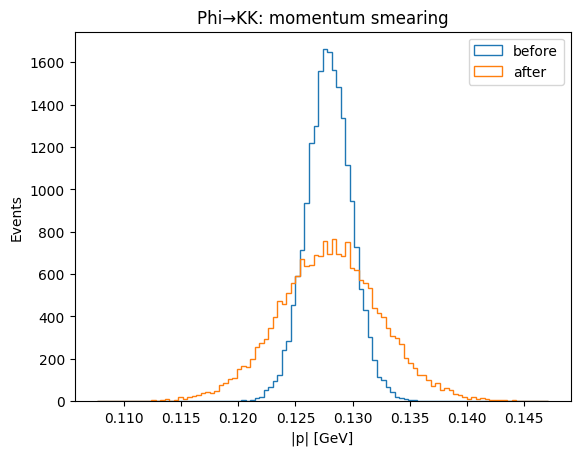

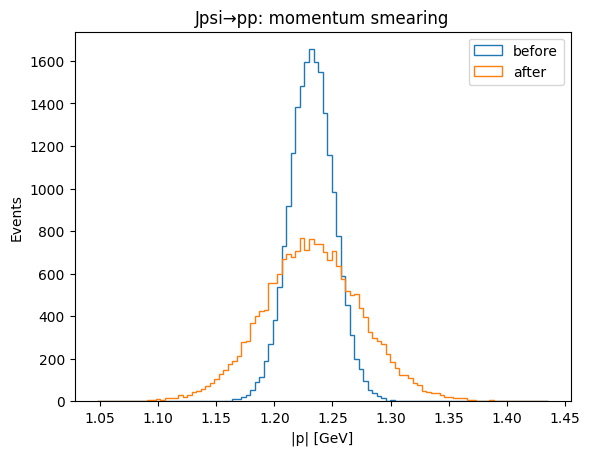

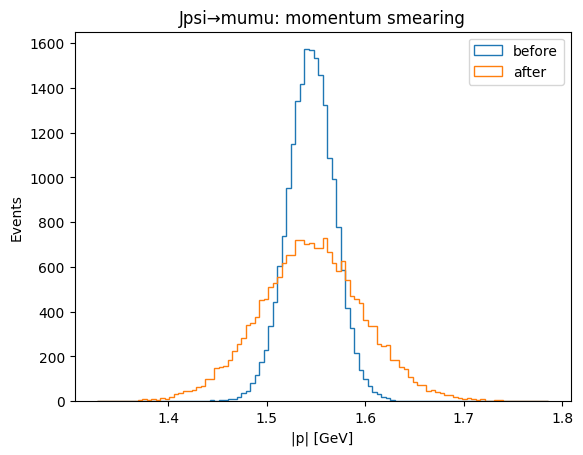

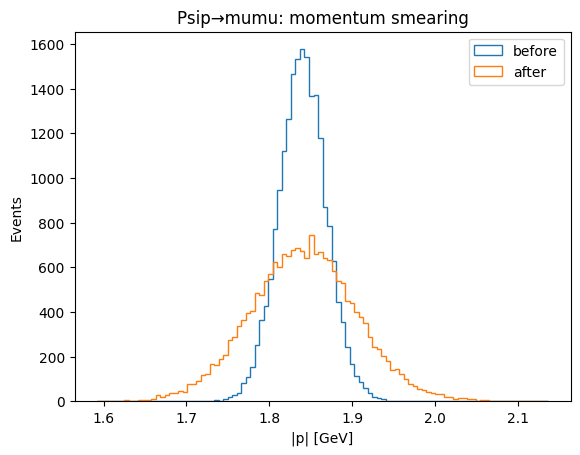

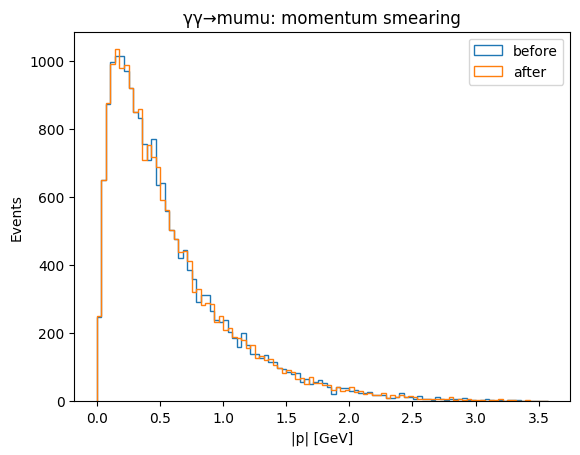

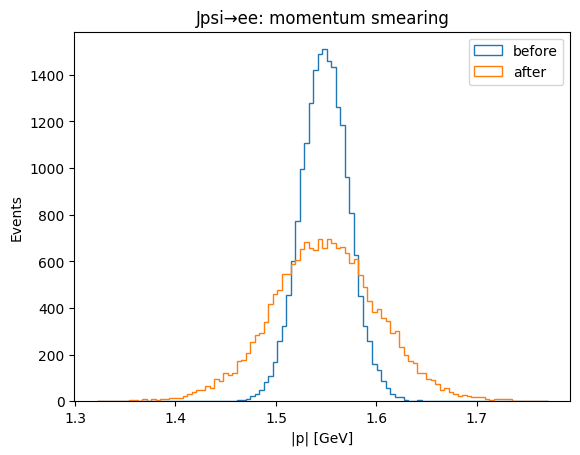

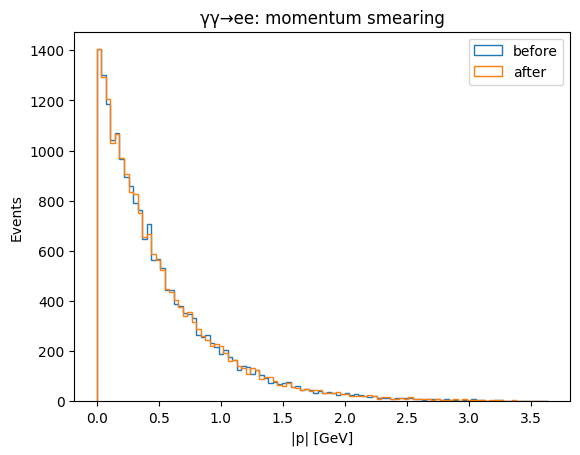

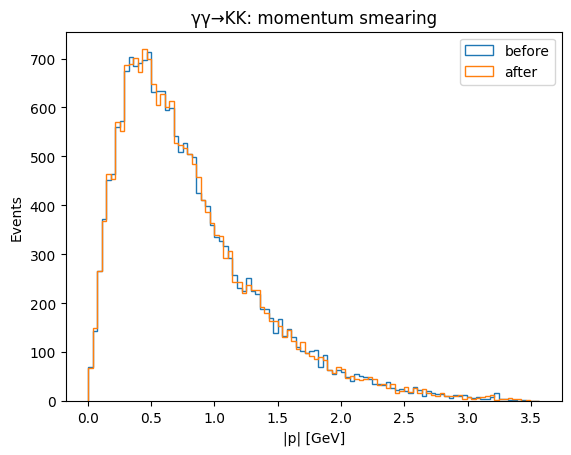

In [339]:
def plot_momentum_comparison(df_before, df_after, process):

    b = df_before[df_before["process"] == process]
    a = df_after[df_after["process"] == process]

    # compute |p|
    p1_b = np.sqrt(b["px1"]**2 + b["py1"]**2 + b["pz1"]**2)
    p1_a = np.sqrt(a["px1"]**2 + a["py1"]**2 + a["pz1"]**2)

    # clean
    p1_b = p1_b.replace([np.inf, -np.inf], np.nan).dropna()
    p1_a = p1_a.replace([np.inf, -np.inf], np.nan).dropna()

    if len(p1_b) == 0 or len(p1_a) == 0:
        print(f"{process}: no data")
        return

    # check spread
    pmin = min(p1_b.min(), p1_a.min())
    pmax = max(p1_b.max(), p1_a.max())

    if np.isclose(pmin, pmax):
        # ultra-narrow → use fixed small window
        center = pmin
        width = 0.01  # GeV (tune if needed)
        bins = 30
        hist_range = (center - width, center + width)
    else:
        bins = min(100, int(np.sqrt(len(p1_b))))
        hist_range = (pmin, pmax)

    plt.hist(p1_b, bins=bins, range=hist_range, histtype="step", label="before")
    plt.hist(p1_a, bins=bins, range=hist_range, histtype="step", label="after")

    plt.xlabel("|p| [GeV]")
    plt.ylabel("Events")
    plt.title(f"{process}: momentum smearing")
    plt.legend()
    plt.show()

plot_momentum_comparison(df_before, df_after, "Phi→KK")
plot_momentum_comparison(df_before, df_after, "Jpsi→pp")
plot_momentum_comparison(df_before, df_after, "Jpsi→mumu")
plot_momentum_comparison(df_before, df_after, "Psip→mumu")
plot_momentum_comparison(df_before, df_after, "γγ→mumu")
plot_momentum_comparison(df_before, df_after, "Jpsi→ee")
plot_momentum_comparison(df_before, df_after, "γγ→ee")
plot_momentum_comparison(df_before, df_after, "γγ→KK")

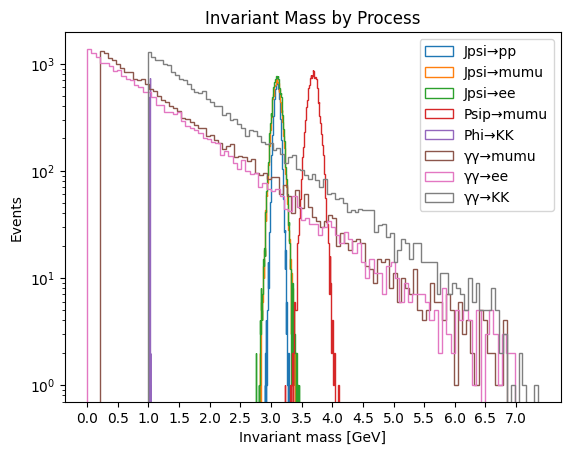

In [340]:
m2 = (
    (df_after["E1"] + df_after["E2"])**2
    - (df_after["px1"] + df_after["px2"])**2
    - (df_after["py1"] + df_after["py2"])**2
    - (df_after["pz1"] + df_after["pz2"])**2
)

df_after["m_inv"] = np.sqrt(np.maximum(m2, 0))

for proc in df_after["process"].unique():
    subset = df_after[df_after["process"] == proc]
    plt.hist(subset["m_inv"], bins=100, histtype="step", label=proc)

plt.xlabel("Invariant mass [GeV]")
plt.ylabel("Events")
plt.xticks(np.arange(0, 7.1, 0.5))
plt.yscale('log')
plt.legend()
plt.title("Invariant Mass by Process")
plt.show()

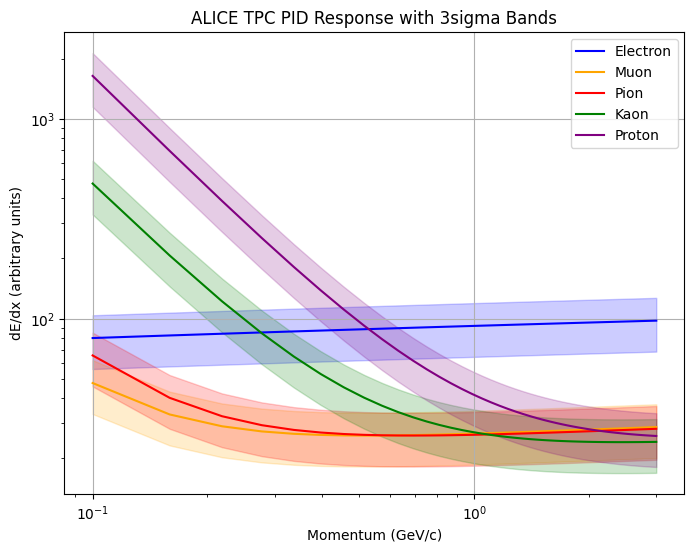

In [341]:
def bethe_bloch(momentum, mass, charge=1):
# Constants for Bethe-Bloch approximation
    K = 0.307075 # MeV mol^-1 cm^2
    Z = charge # Particle charge
    I = 0.000016 # Mean excitation potential (MeV)
    m_e = 0.511 # Electron mass in MeV/c^2
    rho = 1 # Density of the material (relative to water, for simplicity)

# Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

# Bethe-Bloch equation (simplified)
    dEdx = ((K * Z**2 * rho) / (beta**2) * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }

    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass if not found
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3

    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):

    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):

    # Get the mean dE/dx from TPC PID response
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type,stretch_factor)

    # Calculate the extremes for the 3σ band
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)

    # Estimate σ as 1/3rd of the difference between the upper and lower bands
    sigma_dEdx = (upper_band - lower_band) / 6

    # Generate a random dE/dx value from a Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)

    return random_dEdx

    # Example usage
    momentum = .3 # Example momentum in GeV/c
    particle_type = 'proton' # Example particle type
    x=1000 #Amount of random numbers

    rn=[]
    for _ in range(x):

        if (particle_type == 'electron'):
            stretch_factor=1
        elif (particle_type == 'muon'):
            stretch_factor=.41
        elif (particle_type == 'pion'):
            stretch_factor=.41
        elif (particle_type == 'kaon'):
            stretch_factor=.38
        elif (particle_type == 'proton'):
            stretch_factor=.40

    random_value = gaussian_tpc_response(momentum, particle_type, stretch_factor)
    rn.append(random_value)

    print(rn)

    xvalues=[]
    for _ in range(x):
        xvalues.append(momentum)
    print(xvalues)

def plot_tpc_pid_response(momentum_range):
    """
    Plot the TPC PID response and error bands for various particle types.
    """
    # Calculate responses and PID bands for different particle species
    particle_types = {
    'Electron': {'color': 'blue', 'stretch_factor': 1},
    'Muon': {'color': 'orange', 'stretch_factor': 0.41},
    'Pion': {'color': 'red', 'stretch_factor': 0.41},
    'Kaon': {'color': 'green', 'stretch_factor': 0.38},
    'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

# plt.plot(xvalues,rn, color= 'black')
momentum_range = np.linspace(0.1, 3) # Momentum range from 0.1 to 10 GeV/c
plot_tpc_pid_response(momentum_range)
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')  # Log scale for x-axis
plt.yscale('log')  # Log scale for y-axis
plt.title('ALICE TPC PID Response with 3sigma Bands')
plt.legend()
plt.grid(True)
plt.show()

#Generate a momentum range and plot
mass_dict = {
    'electron': 0.000511,
    'muon': 0.10566,
    'pion': 0.13957,
    'kaon': 0.49367,
    'proton': 0.93827
    }




electron 80.0309130202914 97.78387563690868
muon 26.04703247267319 47.681429386370816
pion 26.046765521951805 65.50112067319142
kaon 24.141054363234282 473.97899079403237
proton 25.91568887948957 1636.7405123619078


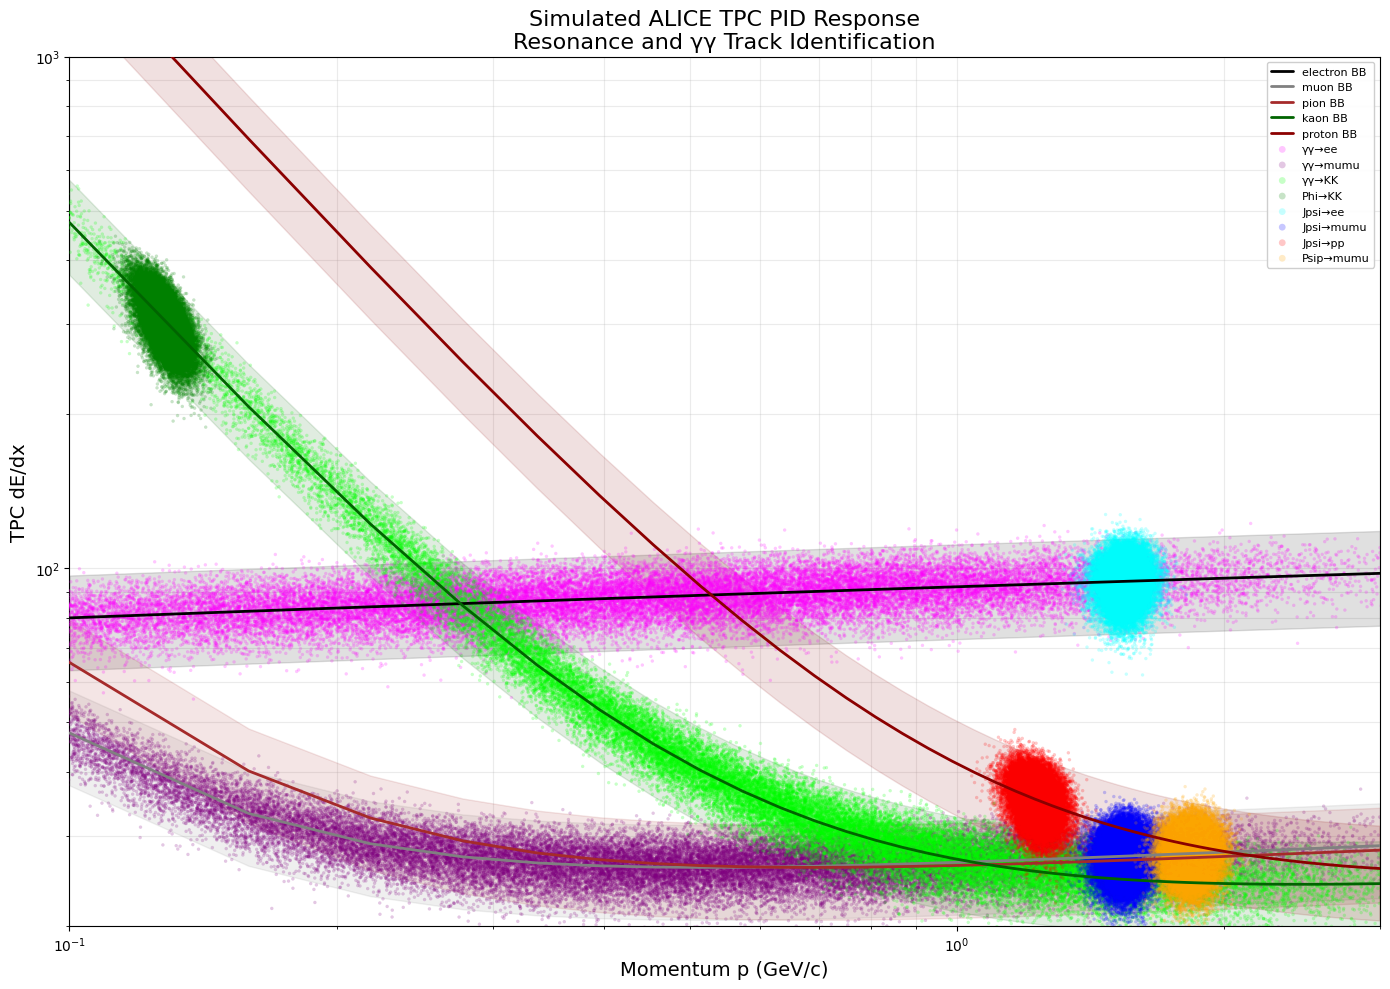


========== PID SUMMARY ==========

particle  identified
electron  electron      76737
          kaon           1090
          muon            411
          pion            477
          proton         1285
kaon      electron        805
          kaon          72308
          muon           3216
          pion           3251
          proton          420
muon      electron        268
          kaon          19491
          muon          41570
          pion          32304
          proton        26367
proton    kaon             38
          muon           1866
          pion             31
          proton        38065
dtype: int64


In [342]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# BETHE-BLOCH TPC PID MODEL
# =========================================================

def bethe_bloch(momentum, mass, charge=1):

    K = 0.307075
    I = 0.000016
    m_e = 0.511
    rho = 1

    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    dEdx = (
        ((K * charge**2 * rho) / (beta**2))
        * (
            0.5 * np.log(
                2 * m_e * beta**2 * gamma**2 / I**2
            )
            - beta**2
        )
    ) * 17

    return dEdx


# =========================================================
# PARTICLE MASSES
# =========================================================

mass_dict = {
    'electron': 0.000511,
    'muon':     0.10566,
    'pion':     0.13957,
    'kaon':     0.49367,
    'proton':   0.93827
}

# Detector response scaling
stretch_dict = {
    'electron': 1.00,
    'muon':     0.41,
    'pion':     0.41,
    'kaon':     0.38,
    'proton':   0.40
}

# =========================================================
# COLORS FOR RESONANCES / TRACKS
# =========================================================

process_colors = {
    "Jpsi→pp": "red",
    "Jpsi→mumu": "blue",
    "Jpsi→ee": "cyan",
    "Psip→mumu": "orange",
    "Phi→KK": "green",
    "γγ→mumu": "purple",
    "γγ→ee": "magenta",
    "γγ→KK": "lime"
}

# =========================================================
# GENERATE TPC RESPONSE
# =========================================================

def generate_tpc_response(momentum, particle_type):

    mass = mass_dict[particle_type]
    stretch = stretch_dict[particle_type]

    mean = bethe_bloch(momentum, mass) * stretch

    sigma = 0.08 * mean

    measured = np.random.normal(mean, sigma)

    return measured, sigma


# =========================================================
# MAP PROCESSES TO PARTICLE TYPES
# =========================================================

pid_map = {
    "Jpsi→pp": "proton",
    "Jpsi→mumu": "muon",
    "Jpsi→ee": "electron",
    "Psip→mumu": "muon",
    "Phi→KK": "kaon",
    "γγ→mumu": "muon",
    "γγ→ee": "electron",
    "γγ→KK": "kaon"
}

# =========================================================
# BUILD TRACK DATASET
# =========================================================

track_data = []

for proc in df_after["process"].unique():

    sub = df_after[df_after["process"] == proc]

    particle_type = pid_map[proc]

    # Track 1
    p1 = np.sqrt(
        sub["px1"]**2 +
        sub["py1"]**2 +
        sub["pz1"]**2
    )

    # Track 2
    p2 = np.sqrt(
        sub["px2"]**2 +
        sub["py2"]**2 +
        sub["pz2"]**2
    )

    # Generate TPC response
    dedx1 = []
    dedx2 = []

    for mom in p1:
        d, s = generate_tpc_response(mom, particle_type)
        dedx1.append(d)

    for mom in p2:
        d, s = generate_tpc_response(mom, particle_type)
        dedx2.append(d)

    temp1 = pd.DataFrame({
        "process": proc,
        "particle": particle_type,
        "momentum": p1,
        "dEdx": dedx1
    })

    temp2 = pd.DataFrame({
        "process": proc,
        "particle": particle_type,
        "momentum": p2,
        "dEdx": dedx2
    })

    track_data.append(temp1)
    track_data.append(temp2)

# Combined PID dataset
pid_df = pd.concat(track_data, ignore_index=True)

# =========================================================
plot_priority = [
    "γγ→ee",
    "γγ→mumu",
    "γγ→KK",
    "Phi→KK",
    "Jpsi→ee",
    "Jpsi→mumu",
    "Jpsi→pp",
    "Psip→mumu"
]

# ---------------------------------------------------------
# Plot tracks with controlled layering
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))



# ---------------------------------------------------------
# CENTRAL BETHE-BLOCH CURVES
# ---------------------------------------------------------

for particle in mass_dict.keys():

    mass = mass_dict[particle]
    stretch = stretch_dict[particle]

    curve = bethe_bloch(momentum_range, mass) * stretch

    sigma_fraction = 0.07
    band = 3 * sigma_fraction * curve

    # --- 3σ shaded region ---
    plt.fill_between(
    momentum_range,
    curve - band,
    curve + band,
    color=particle_colors[particle],
    alpha=0.12,
    zorder=2
)

    # Debug visibility
    print(particle, np.nanmin(curve), np.nanmax(curve))

    plt.plot(
        momentum_range,
        curve,
        color=particle_colors[particle],
        linewidth=2,          # thicker
        linestyle='-',
        alpha=1.0,
        zorder=1000,          # VERY high priority
        solid_capstyle='round',
        label=f"{particle} BB"
    )
for layer, proc in enumerate(plot_priority):

    sub = pid_df[pid_df["process"] == proc].copy()

    # Helps prevent overdrawing artifacts
    sub = sub.sort_values("dEdx")

    plt.scatter(
        sub["momentum"],
        sub["dEdx"],
        s=6,
        alpha=0.22,
        color=process_colors[proc],
        edgecolors='none',
        rasterized=True,
        label=proc,
        zorder=10 + layer
    )

# =========================================================
# STYLE
# =========================================================

plt.xscale("log")
plt.yscale("log")

plt.xlim(0.1, 3)
plt.ylim(20, 1000)

plt.xlabel("Momentum p (GeV/c)", fontsize=14)
plt.ylabel("TPC dE/dx", fontsize=14)

plt.title(
    "Simulated ALICE TPC PID Response\n"
    "Resonance and γγ Track Identification",
    fontsize=16
)

plt.grid(True, which="both", alpha=0.25)

# cleaner legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.legend(
    by_label.values(),
    by_label.keys(),
    fontsize=8,
    loc="upper right",
    framealpha=0.95,
    markerscale=2
)

plt.tight_layout()
plt.show()
# =========================================================
# OPTIONAL: PID CLASSIFICATION
# =========================================================

def identify_particle(momentum, measured_dEdx):

    chi2_results = {}

    for particle in mass_dict.keys():

        mass = mass_dict[particle]
        stretch = stretch_dict[particle]

        expected = (
            bethe_bloch(momentum, mass)
            * stretch
        )

        sigma = 0.08 * expected

        chi2 = (
            (measured_dEdx - expected) / sigma
        )**2

        chi2_results[particle] = chi2

    best_particle = min(
        chi2_results,
        key=chi2_results.get
    )

    return best_particle


# =========================================================
# RUN PID IDENTIFICATION
# =========================================================

pid_df["identified"] = pid_df.apply(
    lambda row: identify_particle(
        row["momentum"],
        row["dEdx"]
    ),
    axis=1
)

# =========================================================
# EFFICIENCY SUMMARY
# =========================================================

print("\n========== PID SUMMARY ==========\n")

summary = (
    pid_df.groupby(
        ["particle", "identified"]
    ).size()
)

print(summary)

In [343]:
#EventId/Particle/Nsigmas:electron,muon,pion,kaon,proton. N sigmas < 0.5
#Grabit by ID sum the canditdates/number of tracks

In [344]:
# =========================================================
# CREATE PID N-SIGMA TABLE
# =========================================================

import numpy as np
import pandas as pd

# =========================================================
# REFERENCE CUT
# =========================================================

N_ref = 0.5

# =========================================================
# EVENT IDS
# =========================================================

# one event id per decay pair
df_after = df_after.reset_index(drop=True)
df_after["event_id"] = np.arange(len(df_after))

# =========================================================
# PID HYPOTHESES
# =========================================================

pid_particles = [
    "proton",
    "kaon",
    "pion",
    "electron",
    "muon"
]

# =========================================================
# PROCESS → TRUE TRACK PARTICLE
# =========================================================

pid_map = {
    "Jpsi→pp": "proton",
    "Jpsi→mumu": "muon",
    "Jpsi→ee": "electron",
    "Psip→mumu": "muon",
    "Phi→KK": "kaon",
    "γγ→mumu": "muon",
    "γγ→ee": "electron",
    "γγ→KK": "kaon"
}

# =========================================================
# COMPUTE N-SIGMAS
# =========================================================

table_rows = []

for idx, row in df_after.iterrows():

    process = row["process"]

    # ---------------------------------------------
    # TRUE particle type
    # ---------------------------------------------

    true_particle = pid_map[process]

    # ---------------------------------------------
    # BOTH TRACKS (+ and -)
    # ---------------------------------------------

    for track in [1, 2]:

        px = row[f"px{track}"]
        py = row[f"py{track}"]
        pz = row[f"pz{track}"]

        momentum = np.sqrt(px**2 + py**2 + pz**2)

        # -----------------------------------------
        # Simulated measured dE/dx
        # -----------------------------------------

        measured_dEdx, sigma_measured = generate_tpc_response(
            momentum,
            true_particle
        )

        # -----------------------------------------
        # Build row
        # -----------------------------------------

        result = {
            "event_id": row["event_id"],
            "track": f"{track}",
            "process": process,
            "true_particle": true_particle,
            "px": px,
            "py": py,
            "pz": pz,
            "p": momentum,
            "measured_dEdx": measured_dEdx
        }

        # -----------------------------------------
        # Compute N_sigma for each PID hypothesis
        # -----------------------------------------

        for particle in pid_particles:

            mass = mass_dict[particle]
            stretch = stretch_dict[particle]

            expected = (
                bethe_bloch(momentum, mass)
                * stretch
            )

            sigma = 0.08 * expected

            n_sigma = (
                measured_dEdx - expected
            ) / sigma

            abs_nsigma = abs(n_sigma)

            # Save N_sigma
            result[f"Nsigma_{particle}"] = abs_nsigma

            # PID cut test
            result[f"{particle}_PID"] = (
                1 if abs_nsigma < N_ref else 0
            )

        table_rows.append(result)

# =========================================================
# FINAL PID TABLE
# =========================================================

pid_table = pd.DataFrame(table_rows)

# =========================================================
# ROUND VALUES
# =========================================================

float_cols = [
    "px", "py", "pz", "p",
    "measured_dEdx"
]

for col in float_cols:
    pid_table[col] = pid_table[col].round(4)

for particle in pid_particles:
    pid_table[f"Nsigma_{particle}"] = (
        pid_table[f"Nsigma_{particle}"]
        .round(3)
    )

# =========================================================
# DISPLAY TABLE
# =========================================================

print("\n================ PID TABLE ================\n")

print(
    pid_table[
        [
            "event_id",
            "track",
            "process",
            "true_particle",

            "px",
            "py",
            "pz",
            "p",

            "Nsigma_proton",
            "proton_PID",

            "Nsigma_kaon",
            "kaon_PID",

            "Nsigma_pion",
            "pion_PID",

            "Nsigma_electron",
            "electron_PID",

            "Nsigma_muon",
            "muon_PID"
        ]
    ].head(20)
)

# =========================================================
# OPTIONAL: SAVE TABLE
# =========================================================

pid_table.to_csv(
    "alice_tpc_pid_table.csv",
    index=False
)

print("\nSaved: alice_tpc_pid_table.csv")


================ PID TABLE ================

    event_id track  process true_particle      px      py      pz       p  \
0          0     1  Jpsi→pp        proton  1.0884 -0.0598 -0.4779  1.1902   
1          0     2  Jpsi→pp        proton -1.1282  0.0643  0.4843  1.2295   
2          1     1  Jpsi→pp        proton -0.9213  0.6947  0.3593  1.2085   
3          1     2  Jpsi→pp        proton  0.9314 -0.6454 -0.3407  1.1833   
4          2     1  Jpsi→pp        proton -1.2506  0.1173  0.1456  1.2645   
5          2     2  Jpsi→pp        proton  1.0206 -0.1321 -0.1489  1.0398   
6          3     1  Jpsi→pp        proton  1.1434 -0.2432  0.4902  1.2676   
7          3     2  Jpsi→pp        proton -1.1099  0.2467 -0.4653  1.2285   
8          4     1  Jpsi→pp        proton  0.6157  1.0457 -0.2574  1.2405   
9          4     2  Jpsi→pp        proton -0.5896 -1.0465  0.2541  1.2278   
10         5     1  Jpsi→pp        proton  0.0864 -0.0393 -1.1943  1.1980   
11         5     2  Jpsi→pp   

In [345]:
# =========================================================
# INPUT: pid_table (from previous step)
# =========================================================

pid_df = pid_table.copy()

pid_particles = ["proton", "kaon", "pion", "electron", "muon"]

# =========================================================
# EVENT LEVEL GROUPING
# =========================================================

event_rows = []

for event_id, group in pid_df.groupby("event_id"):

    event_result = {
        "event_id": event_id,
        "n_tracks": 2   # fixed by construction
    }

    # -----------------------------------------------------
    # SUM PID FLAGS OVER TRACKS
    # -----------------------------------------------------

    for particle in pid_particles:

        col = f"{particle}_PID"

        # sum of 0/1 over 2 tracks → range [0,2]
        pid_sum = group[col].sum()

        event_result[f"{particle}_PID_sum"] = pid_sum

        # optional: event-level decision (both tracks pass)
        #event_result[f"{particle}_FULL_MATCH"] = (
        #    1 if pid_sum == 2 else 0
        #)

        # optional: at least one track passes
        #event_result[f"{particle}_ANY_MATCH"] = (
           # 1 if pid_sum >= 1 else 0
        #)

    event_rows.append(event_result)

# =========================================================
# FINAL EVENT TABLE
# =========================================================

event_table = pd.DataFrame(event_rows)

# =========================================================
# DISPLAY CLEAN VIEW
# =========================================================

print("\n================ EVENT LEVEL PID SUMMARY ================\n")

print(event_table.head(20))

# =========================================================
# OPTIONAL: SAVE
# =========================================================

event_table.to_csv("alice_event_pid_summary.csv", index=False)

print("\nSaved: alice_event_pid_summary.csv")


================ EVENT LEVEL PID SUMMARY ================

    event_id  n_tracks  proton_PID_sum  kaon_PID_sum  pion_PID_sum  \
0          0         2               0             0             0   
1          1         2               0             0             0   
2          2         2               0             0             0   
3          3         2               1             0             0   
4          4         2               2             0             0   
5          5         2               0             0             0   
6          6         2               2             0             0   
7          7         2               0             0             0   
8          8         2               0             0             0   
9          9         2               2             0             0   
10        10         2               0             0             0   
11        11         2               1             0             0   
12        12         2        

In [ ]:
# =========================================================
# REAL DATA GENERATION 
# =========================================================



# ADD PROCESES FIX CODE!



# =========================================================
# NEW PROCESS SET FOR ALL 2 PARTICLE DECAYS
# =========================================================

process_list = [
    "γγ→ee",
    "γγ→mumu",
    "γγ→KK",
    "Jpsi→ee",
    "Jpsi→mumu",
    "Psip→mumu"
]

df_ext = df_after[df_after["process"].isin(process_list)].copy()
df_ext = df_ext.reset_index(drop=True)

# assign event ids again (clean separation for training set)
df_ext["event_id"] = np.arange(len(df_ext))

# =========================================================
# PID SETUP (EXTENDED IF NEEDED)
# =========================================================

pid_particles = ["proton", "kaon", "pion", "electron", "muon",]

pid_map = {
    "γγ→ee": "electron",
    "γγ→mumu": "muon",
    "γγ→KK": "kaon",
    "Jpsi→ee": "electron",
    "Jpsi→mumu": "muon",
    "Psip→mumu": "muon"
}

N_ref = 0.5

# =========================================================
# BUILD TRACK-LEVEL TABLE
# =========================================================

rows = []

for _, row in df_ext.iterrows():

    process = row["process"]
    true_particle = pid_map[process]

    for track in [1, 2]:

        px = row[f"px{track}"]
        py = row[f"py{track}"]
        pz = row[f"pz{track}"]

        momentum = np.sqrt(px**2 + py**2 + pz**2)

        measured_dEdx, _ = generate_tpc_response(momentum, true_particle)

        out = {
            "event_id": row["event_id"],
            "track": track,
            "process": process,
            "true_particle": true_particle,
            "px": px,
            "py": py,
            "pz": pz,
            "p": momentum,
            "measured_dEdx": measured_dEdx
        }

        for particle in pid_particles:

            expected = bethe_bloch(momentum, mass_dict[particle]) * stretch_dict[particle]
            sigma = 0.08 * expected

            n_sigma = abs((measured_dEdx - expected) / sigma)

            out[f"Nsigma_{particle}"] = round(n_sigma, 3)
            out[f"{particle}_PID"] = int(n_sigma < N_ref)

        rows.append(out)

pid_table_ext = pd.DataFrame(rows)

# =========================================================
# ROUNDING
# =========================================================

for col in ["px", "py", "pz", "p", "measured_dEdx"]:
    pid_table_ext[col] = pid_table_ext[col].round(4)

# =========================================================
# EVENT-LEVEL SUMMARY
# =========================================================

event_rows = []

for eid, group in pid_table_ext.groupby("event_id"):

    event_out = {
        "event_id": eid,
        "n_tracks": len(group)
    }

    for particle in pid_particles:
        event_out[f"{particle}_PID_sum"] = group[f"{particle}_PID"].sum()

    event_rows.append(event_out)

event_table_ext = pd.DataFrame(event_rows)

# =========================================================
# DISPLAY TABLES (like previous cells)
# =========================================================

print("\n================ EXTENDED PID TABLE ================\n")
print(pid_table_ext.head(20))

print("\n================ EXTENDED EVENT SUMMARY ================\n")
print(event_table_ext.head(20))

# =========================================================
# SAVE CSV FILES
# =========================================================

pid_table_ext.to_csv("training_pid_table.csv", index=False)
event_table_ext.to_csv("training_event_summary.csv", index=False)

print("\nSaved: training_pid_table.csv")
print("Saved: training_event_summary.csv")


================ EXTENDED PID TABLE ================

    event_id  track    process true_particle      px      py      pz       p  \
0          0      1  Jpsi→mumu          muon  1.2196 -0.8095 -0.3905  1.5150   
1          0      2  Jpsi→mumu          muon -1.3587  0.8413  0.4011  1.6477   
2          1      1  Jpsi→mumu          muon  1.4631 -0.1495 -0.5250  1.5616   
3          1      2  Jpsi→mumu          muon -1.4459  0.1581  0.5228  1.5456   
4          2      1  Jpsi→mumu          muon  1.4956  0.1855  0.0433  1.5076   
5          2      2  Jpsi→mumu          muon -1.4479 -0.1973 -0.0426  1.4619   
6          3      1  Jpsi→mumu          muon  1.1797 -0.0140 -1.0453  1.5762   
7          3      2  Jpsi→mumu          muon -1.2277  0.0136  1.0128  1.5916   
8          4      1  Jpsi→mumu          muon  0.9251 -0.6788  0.9491  1.4891   
9          4      2  Jpsi→mumu          muon -0.9148  0.7034 -0.9269  1.4802   
10         5      1  Jpsi→mumu          muon  0.5436  1.2099 -0.8

# Prompt for ChatGPT
Now I need a "real data" part writen in new code cell for proceses (n = 100 each): gammagamma to e+e-, to Muon+Muon-, to KaonKaon; J/psi to e+e-, to Muon+ Muon-, to proton antiproton; psi(2s) to Muon+Muon- and Pentaquark P_c(4360) to J/psi and proton. Make the data go through the same operations as the training data and put it into 2 separate csv files. Name them starting with "real_data".

In [ ]:
# =========================================================
# "REAL" DATA GENERATION
# =========================================================

process_list = [
    "γγ→ee",
    "γγ→mumu",
    "γγ→KK",
    "Jpsi→ee",
    "Jpsi→mumu",
    "Jpsi→ppbar",
    "Psip→mumu",
]

df_ext = df_after[df_after["process"].isin(process_list)].copy()
df_ext = df_ext.reset_index(drop=True)

# assign event ids again (clean separation for training set)
df_ext["event_id"] = np.arange(len(df_ext))

# =========================================================
# PID SETUP (EXTENDED IF NEEDED)
# =========================================================

pid_particles = ["proton", "kaon", "pion", "electron", "muon"]

pid_map = {
    "γγ→ee": "electron",
    "γγ→mumu": "muon",
    "γγ→KK": "kaon",
    "Jpsi→ee": "electron",
    "Jpsi→mumu": "muon",
    "Psip→mumu": "muon",
    "Jpsi→ppbar": "proton"
}

N_ref = 0.5

# =========================================================
# BUILD TRACK-LEVEL TABLE
# =========================================================

rows = []

for _, row in df_ext.iterrows():

    process = row["process"]
    true_particle = pid_map[process]

    for track in [1, 2]:

        px = row[f"px{track}"]
        py = row[f"py{track}"]
        pz = row[f"pz{track}"]

        momentum = np.sqrt(px**2 + py**2 + pz**2)

        measured_dEdx, _ = generate_tpc_response(momentum, true_particle)

        out = {
            "event_id": row["event_id"],
            "track": track,
            "process": process,
            "true_particle": true_particle,
            "px": px,
            "py": py,
            "pz": pz,
            "p": momentum,
            "measured_dEdx": measured_dEdx
        }

        for particle in pid_particles:

            expected = bethe_bloch(momentum, mass_dict[particle]) * stretch_dict[particle]
            sigma = 0.08 * expected

            n_sigma = abs((measured_dEdx - expected) / sigma)

            out[f"Nsigma_{particle}"] = round(n_sigma, 3)
            out[f"{particle}_PID"] = int(n_sigma < N_ref)

        rows.append(out)

pid_table_ext = pd.DataFrame(rows)

# =========================================================
# ROUNDING
# =========================================================

for col in ["px", "py", "pz", "p", "measured_dEdx"]:
    pid_table_ext[col] = pid_table_ext[col].round(4)

# =========================================================
# EVENT-LEVEL SUMMARY
# =========================================================

event_rows = []

for eid, group in pid_table_ext.groupby("event_id"):

    event_out = {
        "event_id": eid,
        "n_tracks": len(group)
    }

    for particle in pid_particles:
        event_out[f"{particle}_PID_sum"] = group[f"{particle}_PID"].sum()

    event_rows.append(event_out)

event_table_ext = pd.DataFrame(event_rows)

# =========================================================
# DISPLAY TABLES (like previous cells)
# =========================================================

print("\n================ EXTENDED PID TABLE ================\n")
print(pid_table_ext.head(20))

print("\n================ EXTENDED EVENT SUMMARY ================\n")
print(event_table_ext.head(20))

# =========================================================
# SAVE CSV FILES
# =========================================================

pid_table_ext.to_csv("real_pid_table.csv", index=False)
event_table_ext.to_csv("real_event_summary.csv", index=False)

print("\nSaved: real_pid_table.csv")
print("Saved: real_event_summary.csv")

# Added functionality imported from generation.ipynb
This cell was appended automatically to restore missing generators and helper functions.

In [ ]:
# Function to generate energies and momenta of daughter particles from the dacay of a parent particle at rest
def decay_generator(M, m):
    # Generate energies and momenta
    E = E = M/2
    p_val = 0.5 * np.sqrt(M**2 - 4* m**2)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)

    px = p_val * np.sin(theta) * np.cos(phi)
    py = p_val * np.sin(theta) * np.sin(phi)
    pz = p_val * np.cos(theta)

    p1 = np.array([E, px, py, pz])
    p2 = np.array([E, -px, -py, -pz])

    return p1, p2

# Function to calculate invariant mass
def invariant_mass(p1, p2):
    E = p1[0] + p2[0]
    px = p1[1] + p2[1]
    py = p1[2] + p2[2]
    pz = p1[3] + p2[3]

    return np.sqrt(E**2 - px**2 - py**2 - pz**2)

# Function to calculate absolute momentum value
def momentum_value(p):
    p_val = np.sqrt(p[1]**2 + p[2]**2 + p[3]**2)
    
    return p_val

# === Imported from generation.ipynb ===

# Function to create N samples of invariant masses from the dacay of a particle of mass M at rest (without smearing)
def sample_M(M, m, N_samples):
    masses_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        if N_samples == 1:
            return inv_m
        masses_sig.append(inv_m)
    return masses_sig

# === Imported from generation.ipynb ===

#Function to create N samples of invariant masses from the decay of a particle of mass M at rest (with smearing)
def sample_M_smeared(M, m, N_samples, rel_sigma=0.03):
    masses_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_smear = [_, px1_s, py1_s, pz1_s]
        p2_smear = [_, px2_s, py2_s, pz2_s]

        p_squared = p1_smear[1]**2 + p1_smear[2]**2 + p1_smear[3]**2
        E = np.sqrt(p_squared + m**2)
        p1_smear[0] = E
        p2_smear[0] = E

        inv_m = invariant_mass(p1_smear, p2_smear)

        if N_samples == 1:
            return inv_m
        
        masses_smear.append(inv_m)

    return masses_smear

# === Imported from generation.ipynb ===

# Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (without smearing)
def sample_p(M, m, N_samples):
    momentum_sig = []
    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)
        #p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        daughters = [p1, p2]
        if N_samples == 1:
            return daughters
        momentum_sig.append(daughters)
    return momentum_sig

# === Imported from generation.ipynb ===

#Function to create N samples of daughter particles momentum distribution from the decay of a particle of mass M at rest (with smearing)
def sample_p_smeared(M, m, N_samples, rel_sigma=0.03):
   
    momentum_smear = []

    for _ in range(N_samples):
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_sq = px1_s**2 + py1_s**2 + pz1_s**2
        p2_sq = px2_s**2 + py2_s**2 + pz2_s**2
        E1_s = np.sqrt(p1_sq + m**2)
        E2_s = np.sqrt(p2_sq + m**2)

        p1_s = np.array([E1_s, px1_s, py1_s, pz1_s])
        p2_s = np.array([E2_s, px2_s, py2_s, pz2_s])

        daughters = [p1_s, p2_s]
        if N_samples == 1:
            return daughters
        #p_val_smear = np.sqrt(px_s**2 + py_s**2 + pz_s**2)
        momentum_smear.append(daughters)
    return momentum_smear

# === Imported from generation.ipynb ===

# Function to create N samples of invariant masses from the two photon interaction with exponential mass distribution (without smearing)
def sample_exp(M_max, m, N_samples):
    masses_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)
        inv_m = invariant_mass(p1, p2)
        if N_samples == 1:
            return inv_m
        masses_bkg.append(inv_m)
    return masses_bkg

# === Imported from generation.ipynb ===

# Function to create N samples of invariant masses from the two photon interaction with exponential mass distribution (with smearing)
def sample_exp_smeared(M_max, m, N_samples, rel_sigma=0.03):
    masses_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_smear = [_, px1_s, py1_s, pz1_s]
        p2_smear = [_, px2_s, py2_s, pz2_s]

        p_squared = p1_smear[1]**2 + p1_smear[2]**2 + p1_smear[3]**2
        E = np.sqrt(p_squared + m**2)
        p1_smear[0] = E
        p2_smear[0] = E

        inv_m = invariant_mass(p1_smear, p2_smear)
        
        if N_samples == 1:
            return inv_m
        masses_bkg.append(inv_m)
    return masses_bkg

# === Imported from generation.ipynb ===

# Function to create N samples of daughter particles momentum distribution from the two photon interaction with exponential mass distribution (without smearing)
def sample_p_exp(M_max, m, N_samples):
    momentum_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)

        daughters = [p1, p2]

        if N_samples == 1:
            return daughters
        
        #p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_bkg.append(daughters)
    return momentum_bkg

# === Imported from generation.ipynb ===

# Function to create N samples of daughter particles momentum distribution from the two photon interaction with exponential mass distribution (with smearing)
def sample_p_exp_smeared(M_max, m, N_samples, rel_sigma=0.03):
    momentum_bkg = []
    for _ in range(N_samples):
        while True:
            M = np.random.exponential(scale=1.0) + (2*m)
            if M < M_max:
                break
        p1, p2 = decay_generator(M, m)

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)

        p1_sq = px1_s**2 + py1_s**2 + pz1_s**2
        p2_sq = px2_s**2 + py2_s**2 + pz2_s**2
        E1_s = np.sqrt(p1_sq + m**2)
        E2_s = np.sqrt(p2_sq + m**2)

        p1_s = np.array([E1_s, px1_s, py1_s, pz1_s])
        p2_s = np.array([E2_s, px2_s, py2_s, pz2_s])

        daughters = [p1_s, p2_s]

        if N_samples == 1:
            return daughters
        
        #p_val = np.sqrt(p1[1]**2 + p1[2]**2 + p1[3]**2)
        momentum_bkg.append(daughters)
    return momentum_bkg

# === Imported from generation.ipynb ===

# Set of functions to generate 4-vectors of daughter particles from a pentaquark decay at rest into proton, muon, antimuon
def two_body_decay(M, m1, m2):
    # Generate energies and momenta
    E1 = (M**2 + m1**2 - m2**2)/(2*M)
    E2 = (M**2 + m2**2 - m1**2)/(2*M)

    p1_val = np.sqrt(E1**2 - m1**2)

    cos_theta = np.random.uniform(-1, 1)
    theta = np.arccos(cos_theta)
    phi = np.random.uniform(0, 2*np.pi)

    px1 = p1_val * np.sin(theta) * np.cos(phi)
    py1 = p1_val * np.sin(theta) * np.sin(phi)
    pz1 = p1_val * np.cos(theta)

    p1 = np.array([E1, px1, py1, pz1])
    p2 = np.array([E2, -px1, -py1, -pz1])

    return p1, p2


def lorentz_boost(p4, beta_vec):

    beta2 = np.dot(beta_vec, beta_vec)

    if beta2 >= 1.0:
        raise ValueError("Boost velocity must satisfy |beta| < 1")

    gamma = 1.0 / np.sqrt(1.0 - beta2)

    E = p4[0]
    p = p4[1:]

    bp = np.dot(beta_vec, p)

    if beta2 > 0:
        gamma2 = (gamma - 1.0) / beta2
    else:
        gamma2 = 0.0

    boosted_p = (p + gamma2 * bp * beta_vec + gamma * E * beta_vec)
    boosted_E = gamma * (E + bp)

    return np.array([boosted_E, *boosted_p])


def generate_pc_decay(
    M_pc=4.312,      # GeV
    M_p=0.938272,    # proton mass
    M_jpsi=3.0969,   # J/psi mass
    M_mu=0.105658    # muon mass
    ):
    # ------------------------------------------------------------
    # 1) P_c -> proton + J/psi in P_c rest frame
    # ------------------------------------------------------------
    proton, jpsi = two_body_decay(M_pc, M_p, M_jpsi)

    # ------------------------------------------------------------
    # 2) J/psi -> mu+ + mu- in J/psi rest frame
    # ------------------------------------------------------------
    mu_plus_rest, mu_minus_rest = two_body_decay(
        M_jpsi,
        M_mu,
        M_mu
    )

    # ------------------------------------------------------------
    # 3) Boost muons according to J/psi momentum
    # ------------------------------------------------------------
    beta_jpsi = jpsi[1:] / jpsi[0]

    mu_plus = lorentz_boost(mu_plus_rest, beta_jpsi)
    mu_minus = lorentz_boost(mu_minus_rest, beta_jpsi)

    return proton, mu_plus, mu_minus

def smear_Pc(N_samples=1, rel_sigma=0.03):

    momentum_smear = []

    for _ in range(N_samples):
        p1, p2, p3 = generate_pc_decay()

        px1_s = np.random.normal(p1[1], abs(p1[1]) * rel_sigma)
        py1_s = np.random.normal(p1[2], abs(p1[2]) * rel_sigma)
        pz1_s = np.random.normal(p1[3], abs(p1[3]) * rel_sigma)
        px2_s = np.random.normal(p2[1], abs(p2[1]) * rel_sigma)
        py2_s = np.random.normal(p2[2], abs(p2[2]) * rel_sigma)
        pz2_s = np.random.normal(p2[3], abs(p2[3]) * rel_sigma)
        px3_s = np.random.normal(p3[1], abs(p3[1]) * rel_sigma)
        py3_s = np.random.normal(p3[2], abs(p3[2]) * rel_sigma)
        pz3_s = np.random.normal(p3[3], abs(p3[3]) * rel_sigma)

        p1_sq = px1_s**2 + py1_s**2 + pz1_s**2
        p2_sq = px2_s**2 + py2_s**2 + pz2_s**2
        p3_sq = px3_s**2 + py3_s**2 + pz3_s**2
        E1_s = np.sqrt(p1_sq + 0.938272**2)
        E2_s = np.sqrt(p2_sq + 0.105658**2)
        E3_s = np.sqrt(p3_sq + 0.105658**2)

        p1_s = np.array([E1_s, px1_s, py1_s, pz1_s])
        p2_s = np.array([E2_s, px2_s, py2_s, pz2_s])
        p3_s = np.array([E3_s, px3_s, py3_s, pz3_s])

        daughters = [p1_s, p2_s, p3_s]

        if N_samples == 1:
            return daughters

        momentum_smear.append(daughters)
    return momentum_smear

# === Imported from generation.ipynb ===

def generate_plot_and_table(momentum_range, continuum, resonances, N_continuum=1000, N_resonances=1000, draw_plot=True):
    # Hipotezy, dla których będziemy wyliczać N-sigmę
    hypotheses = [
        ('electron', 1),
        ('muon', 0.41),
        ('pion', 0.41),
        ('kaon', 0.38),
        ('proton', 0.4)
    ]

    all_tracks = []
    event_id = 0

    if draw_plot == True:
        plot_tpc_pid_response(momentum_range)
    
    # Generowanie danych dla kontinuum
    for reaction in continuum:
        reaction_name, m, pid_true, color, stretch = reaction
        # Korzystamy z wcześniej zdefiniowanej funkcji generującej pędy
        momenta_vec = sample_p_exp_smeared(7.0, m, N_continuum)
        
        momenta_val = []
        # Obliczamy pędy całkowite dla obu cząstek potomnych w każdym zdarzeniu
        for event in momenta_vec:
            momenta_val.extend([momentum_value(event[0]), momentum_value(event[1])])
            
        momenta_val = np.array(momenta_val)
        dedx, low, high = tpc_pid_response(momenta_val, pid_true, stretch)
        sigma = (high - low) / 6
        dedx_smeared = np.random.normal(dedx, sigma)

        # Obliczanie N-sigmy dla wszystkich wektorów jednocześnie (wektoryzacja Numpy)
        nsigmas_exp = {}
        for hyp, stretch_hyp in hypotheses:
            exp_dedx, exp_low, exp_high = tpc_pid_response(momenta_val, hyp, stretch_hyp)
            exp_sigma = (exp_high - exp_low) / 6
            nsigmas_exp[hyp] = (dedx_smeared - exp_dedx) / exp_sigma
        
        # Rysowanie punktów na wykresie
        if draw_plot == True:
            plt.scatter(momenta_val, dedx_smeared, color=color, s=5, alpha=0.4, label=reaction_name)
        
        # Zapisywanie informacji o wygenerowanych śladach do tabeli
        idx = 0
        for event in momenta_vec:
            for particle_idx in (0, 1):
                all_tracks.append({
                    'EventID': event_id,
                    'Reaction': reaction_name,
                    'PID_true': pid_true,
                    'Px': event[particle_idx][1], 
                    'Py': event[particle_idx][2], 
                    'Pz': event[particle_idx][3],
                    'p': momenta_val[idx],
                    'E': event[particle_idx][0],
                    'dEdx': dedx_smeared[idx],
                    'Nsigma_e': nsigmas_exp['electron'][idx],
                    'Nsigma_mu': nsigmas_exp['muon'][idx],
                    'Nsigma_pi': nsigmas_exp['pion'][idx],
                    'Nsigma_K': nsigmas_exp['kaon'][idx],
                    'Nsigma_p': nsigmas_exp['proton'][idx]
                })
                idx += 1
            event_id += 1

    # Generowanie danych dla rezonansów
    for reaction in resonances:
        reaction_name, M, m, pid_true, color, stretch = reaction
        momenta_vec = sample_p_smeared(M, m, N_resonances)
        
        momenta_val_res = []
        for event in momenta_vec:
            momenta_val_res.extend([momentum_value(event[0]), momentum_value(event[1])])
            
        momenta_val_res = np.array(momenta_val_res)
        dedx, low, high = tpc_pid_response(momenta_val_res, pid_true, stretch)
        sigma = (high - low) / 6
        dedx_smeared = np.random.normal(dedx, sigma)

        # Obliczanie N-sigmy dla rezonansów
        nsigmas_res = {}
        for hyp, strech_hyp in hypotheses:
            exp_dedx, exp_low, exp_high = tpc_pid_response(momenta_val_res, hyp, stretch_hyp)
            exp_sigma = (exp_high - exp_low) / 6
            nsigmas_res[hyp] = (dedx_smeared - exp_dedx) / exp_sigma
        
        # Rysowanie punktów na wykresie
        if draw_plot == True:
            plt.scatter(momenta_val_res, dedx_smeared, color=color, s=5, alpha=0.4, label=reaction_name)
        
        # Zapisywanie informacji o wygenerowanych śladach do tabeli
        idx = 0
        for event in momenta_vec:
            for particle_idx in (0, 1):
                all_tracks.append({
                    'EventID': event_id,
                    'Reaction': reaction_name,
                    'PID_true': pid_true,
                    'Px': event[particle_idx][1], 
                    'Py': event[particle_idx][2], 
                    'Pz': event[particle_idx][3],
                    'p': momenta_val_res[idx],
                    'E': event[particle_idx][0],
                    'dEdx': dedx_smeared[idx],
                    'Nsigma_e': nsigmas_res['electron'][idx],
                    'Nsigma_mu': nsigmas_res['muon'][idx],
                    'Nsigma_pi': nsigmas_res['pion'][idx],
                    'Nsigma_K': nsigmas_res['kaon'][idx],
                    'Nsigma_p': nsigmas_res['proton'][idx]
                })
                idx += 1
            event_id += 1

    # Stylizacja wykresu
    if draw_plot == True:
        plt.xlabel('Momentum (GeV/c)')
        plt.ylabel('dE/dx (arbitrary units)')
        plt.xscale('log')
        plt.yscale('log')
        plt.title('ALICE TPC PID Response with Tracks and Simulated Data Points')
        plt.xlim(0.1, 4)
        plt.ylim(0, 5000)
        plt.legend(ncol=2)
        plt.grid(True)
        plt.show()

    # Zwrócenie tabeli w postaci DataFrame
    df = pd.DataFrame(all_tracks)
    return df

# === Imported from generation.ipynb ===

def create_event_summary_table(df):

    event_rows = []

    grouped = df.groupby("EventID")

    for evid, group in grouped:

        # candidate counts
        n_electron = np.sum(np.abs(group["Nsigma_e"]) < 0.5)
        n_muon    = np.sum(np.abs(group["Nsigma_mu"]) < 0.5)
        n_pion    = np.sum(np.abs(group["Nsigma_pi"]) < 0.5)
        n_kaon    = np.sum(np.abs(group["Nsigma_K"]) < 0.5)
        n_proton  = np.sum(np.abs(group["Nsigma_p"]) < 0.5)

        # total tracks
        n_tracks = len(group)

        # four-momentum sums
        E_tot  = group["E"].sum()
        px_tot = group["Px"].sum()
        py_tot = group["Py"].sum()
        pz_tot = group["Pz"].sum()

        # invariant mass
        m2 = E_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2
        inv_mass = np.sqrt(max(m2, 0))  # protect against tiny negative values

        event_rows.append({
            "EventID": evid,

            "N_ElectronCandidates": int(n_electron),
            "N_MuonCandidates": int(n_muon),
            "N_PionCandidates": int(n_pion),
            "N_KaonCandidates": int(n_kaon),
            "N_ProtonCandidates": int(n_proton),

            "N_Tracks": n_tracks,

            "invMass": inv_mass
        })

    return pd.DataFrame(event_rows)

# === Imported from generation.ipynb ===

def generate_Pc_table(momentum_range, N_samples=10):
    # Hipotezy, dla których będziemy wyliczać N-sigmę
    hypotheses = [
        ('electron', 1),
        ('muon', 0.41),
        ('pion', 0.41),
        ('kaon', 0.38),
        ('proton', 0.4)
    ]

    all_tracks = []
    event_id = 0
    
    momenta_vec = smear_Pc(N_samples)
    momenta_val = []
    # Obliczamy pędy całkowite dla wszystkich cząstek potomnych w każdym zdarzeniu
    for event in momenta_vec:
        momenta_val.extend([momentum_value(event[0]), momentum_value(event[1]), momentum_value(event[2])])

    momenta_val = np.array(momenta_val)
    proton_idx = np.arange(0, len(momenta_val), 3)
    muon_idx = np.array([i for i in range(len(momenta_val)) if i % 3 != 0])

    proton_mom = momenta_val[proton_idx]
    muon_mom = momenta_val[muon_idx]
            
    dedx_p, low_p, high_p = tpc_pid_response(proton_mom, 'proton', 0.4)
    sigma_p = (high_p - low_p) / 6
    dedx_p_smeared = np.random.normal(dedx_p, sigma_p)

    dedx_mu, low_mu, high_mu = tpc_pid_response(muon_mom, 'muon', 0.41)
    sigma_mu = (high_mu - low_mu) / 6
    dedx_mu_smeared = np.random.normal(dedx_mu, sigma_mu)

    # Obliczanie N-sigmy dla wszystkich wektorów jednocześnie (wektoryzacja Numpy)
    nsigmas_mu = {}
    nsigmas_p = {}
    for hyp, stretch_hyp in hypotheses:
        exp_p_dedx, exp_p_low, exp_p_high = tpc_pid_response(proton_mom, hyp, stretch_hyp)
        exp_p_sigma = (exp_p_high - exp_p_low) / 6
        nsigmas_p[hyp] = (dedx_p_smeared - exp_p_dedx) / exp_p_sigma

        exp_mu_dedx, exp_mu_low, exp_mu_high = tpc_pid_response(muon_mom, hyp, stretch_hyp)
        exp_mu_sigma = (exp_mu_high - exp_mu_low) / 6
        nsigmas_mu[hyp] = (dedx_mu_smeared - exp_mu_dedx) / exp_mu_sigma
         
    # Zapisywanie informacji o wygenerowanych śladach do tabeli
    p_idx = 0
    mu_idx = 0

    for event in momenta_vec:

        # PROTON
        all_tracks.append({
            'EventID': event_id,
            'Reaction': 'Pc → p μ μ',
            'PID_true': 'proton',
            'Px': event[0][1],
            'Py': event[0][2],
            'Pz': event[0][3],
            'p': proton_mom[p_idx],
            'E': event[0][0],
            'dEdx': dedx_p_smeared[p_idx],
            'Nsigma_e': nsigmas_p['electron'][p_idx],
            'Nsigma_mu': nsigmas_p['muon'][p_idx],
            'Nsigma_pi': nsigmas_p['pion'][p_idx],
            'Nsigma_K': nsigmas_p['kaon'][p_idx],
            'Nsigma_p': nsigmas_p['proton'][p_idx]
        })

        p_idx += 1

        # TWO MUONS
        for particle_idx in (1, 2):

            all_tracks.append({
                'EventID': event_id,
                'Reaction': 'Pc → p μ μ',
                'PID_true': 'muon',
                'Px': event[particle_idx][1],
                'Py': event[particle_idx][2],
                'Pz': event[particle_idx][3],
                'p': muon_mom[mu_idx],
                'E': event[particle_idx][0],
                'dEdx': dedx_mu_smeared[mu_idx],
                'Nsigma_e': nsigmas_mu['electron'][mu_idx],
                'Nsigma_mu': nsigmas_mu['muon'][mu_idx],
                'Nsigma_pi': nsigmas_mu['pion'][mu_idx],
                'Nsigma_K': nsigmas_mu['kaon'][mu_idx],
                'Nsigma_p': nsigmas_mu['proton'][mu_idx]
            })

            mu_idx += 1

        event_id += 1

    # Zwrócenie tabeli w postaci DataFrame
    df = pd.DataFrame(all_tracks)
    return df

# Added invariant-mass reconstruction
- Adds `m_inv_reco` to all two-body event tables
- Adds pentaquark and dimuon invariant-mass reconstruction helpers

In [ ]:

# =====================================================
# Invariant-mass utilities added automatically
# =====================================================
import numpy as np

def invariant_mass_from_columns(df):
    px = df["px1"] + df["px2"]
    py = df["py1"] + df["py2"]
    pz = df["pz1"] + df["pz2"]
    E  = df["E1"]  + df["E2"]
    return np.sqrt(np.maximum(E**2 - px**2 - py**2 - pz**2, 0))

# Add invariant mass for all 2-body processes
if "process" in df.columns:
    df["m_inv_reco"] = invariant_mass_from_columns(df)

# Pentaquark invariant masses
def pentaquark_invariant_masses(proton, mu_plus, mu_minus):
    p_tot = proton + mu_plus + mu_minus
    jpsi = mu_plus + mu_minus

    m_pc = np.sqrt(max(p_tot[0]**2 - np.sum(p_tot[1:]**2), 0))
    m_jpsi = np.sqrt(max(jpsi[0]**2 - np.sum(jpsi[1:]**2), 0))

    return {
        "m_pentaquark": m_pc,
        "m_mumu": m_jpsi
    }

def generate_Pc_table_with_masses(N=1000):
    rows = []
    for _ in range(N):
        p, mu_p, mu_m = generate_pc_decay()
        masses = pentaquark_invariant_masses(p, mu_p, mu_m)

        rows.append({
            "m_pentaquark": masses["m_pentaquark"],
            "m_mumu": masses["m_mumu"],
            "Ep": p[0], "E_mu+": mu_p[0], "E_mu-": mu_m[0]
        })

    import pandas as pd
    return pd.DataFrame(rows)

print("Invariant-mass columns/functions added.")
